# Version 2: Redox-Balanced Model of the Great Oxidation Event

## Conceptual Framework (v2)

- Oxygenic photosynthesis produces O₂ and reduced organic matter (CH₂O) as a coupled redox pair
- This process does not change the net redox state of the system
- Most CH₂O is reprocessed through microbial and geochemical pathways that consume O₂
- Oxygen accumulation requires removal of reducing power from the system via:
    - burial of organic carbon
    - escape of hydrogen to space
- Geological and atmospheric processes therefore control long-term oxygen levels

## Model Variables

- **B(t):** Cyanobacteria biomass
- **O(t):** Atmospheric oxygen
- **R(t):** Reduced reservoir

## New Terms Introduced

Burial term **(𝛽𝐵)**


Hydrogen escape term **(ϵ)** 

## Governing Equations


**𝑑𝐵𝑑𝑡 = 𝑟𝐵(1−𝐵/𝐾)**

**𝑑𝑂𝑑𝑡 = 𝛽𝐵 + 𝜖 − 𝛾𝑂𝑅**   
> i.e.,  burial + H escape - oxidation rxn
    
**𝑑𝑅𝑑𝑡 = 𝑉 − 𝛾𝑂𝑅 − 𝛽𝐵**

## Updated Assumptions

- Redox balance is enforced at system level
- Burial removes reduced carbon from active cycle
- Hydrogen escape is a constant loss of reducing power
- System remains well-mixed

## Parameter Definition

| Parameter | Meaning              |
| --------- | -------------------- |
| r         | growth rate          |
| K         | carrying capacity    |
| γ         | oxidation rate       |
| V         | volcanic flux        |
| β         | burial efficiency    |
| ε         | hydrogen escape rate |

In [17]:
## import necessary Libraries

import numpy as np 
import matplotlib.pyplot as plt # differential equation solver
from scipy.integrate import solve_ivp 

In [23]:
## Initial Conditions

B0 = 0.01     # Initial cyanobacteria biomass
O0 = 0.0      # Initial oxygen concentration
R0 = 1.0      # Initial reduced reservoir
Y0 = [B0, O0, R0]

In [37]:
## Parameter values

r = 0.1       # intrinsic growth rate
K = 1.0       # Carrying capacity

γ = 0.01      # Oxidation rate constant
β = 0.002          # burial efficiency    
ε = 0.005         # hydrogen escape rate 

V = 0.003     # Volcanic flux

In [38]:
# Model implementation
def goe_model_v2(t, y):
    B, O, R = y
    
    dBdt = r*B * (1 - B/K)
    dOdt = β*B + ε - γ*O*R
    dRdt = V - γ*O*R - β*B
    
    return [dBdt, dOdt, dRdt]

## Simulation

In [40]:
# time span for simulation

t_span = (0, 1000)  
t_eval = np.linspace(0,100,1000) # time points for evaluation

In [41]:
# solve system
sol = solve_ivp(goe_model_v2, 
                t_span, 
                Y0, 
                t_eval=t_eval,
               )

In [42]:
B= sol.y[0] 
O= sol.y[1] 
R= sol.y[2]

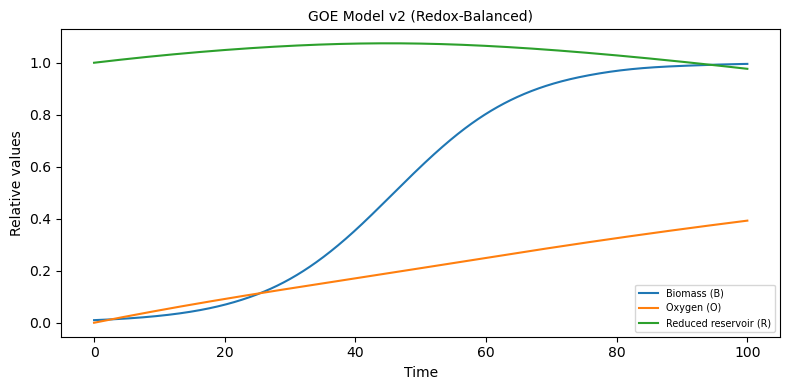

In [57]:
# Plot 

plt.figure(figsize=(8,4))

plt.plot(t_eval, B, label="Biomass (B)")
plt.plot(t_eval, O, label="Oxygen (O)")
plt.plot(t_eval, R, label="Reduced reservoir (R)")

plt.xlabel("Time")
plt.ylabel("Relative values")
plt.title("GOE Model v2 (Redox-Balanced)", fontsize= 10)

plt.legend(fontsize= 'x-small')

plt.tight_layout()
plt.savefig('plot.png', dpi=300)
plt.show()

## Sensitivity Analysis 

Does O₂ accumulate only when:
- burial is active?
- escape is active?

In [45]:
## Results

## Comparison to v1

| v1                         | v2                                      |
| -------------------------- | --------------------------------------- |
| Production vs sinks        | Redox balance                           |
| Photosynthesis as source   | Burial + escape as net source           |
| O₂ rises when sinks weaken | O₂ rises when reducing power is removed |


In [47]:
## Conclusion